## Cell 1: Install Dependencies


In [1]:
!pip install timm pycocotools torchmetrics scikit-learn matplotlib seaborn pyyaml tqdm -q
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")


GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128


## Cell 2: Clone Repository (source code + trained models)


In [2]:
import os, sys
from pathlib import Path

REPO_URL = 'https://github.com/Thinh59/ECAAL.git'
REPO_DIR = Path('/kaggle/working/ECAAL')

if REPO_DIR.exists():
    print('Repo exists — pulling latest...')
    os.system(f'git -C {REPO_DIR} pull')
else:
    print(f'Cloning {REPO_URL} ...')
    ret = os.system(f'git clone {REPO_URL} {REPO_DIR}')
    if ret != 0:
        raise RuntimeError('git clone failed!')

sys.path.insert(0, str(REPO_DIR / 'src'))
print('Repository OK!')


Cloning https://github.com/Thinh59/ECAAL.git ...


Cloning into '/kaggle/working/ECAAL'...


Repository OK!


## Cell 3: Setup — Copy Trained Models to Working Dir


In [3]:
import shutil, json
from pathlib import Path

OUTPUTS_DIR = Path('/kaggle/working/outputs')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Giữ nguyên đường dẫn root
DATASET_ROOT = Path('/kaggle/input/datasets/thinhha59/models') 
RESULTS_DIR  = DATASET_ROOT / 'results'

# SỬA Ở ĐÂY: Thêm RESULTS_DIR vào trước
SRC_SUBSET   = RESULTS_DIR / 'data' / 'coco_subset' 

EXPS = [
    'exp_A_resnet_bce',
    'exp_B_resnet_asl',
    'exp_C_efficientnet_cbam_asl',
    'exp_D_resnet_focal',
    'exp_E_resnet_cbam_asl',
    'exp_F_efficientnet_asl',
]

print(f"Checking models in: {RESULTS_DIR}")
for exp in EXPS:
    src = RESULTS_DIR / exp
    dst = OUTPUTS_DIR / exp
    dst.mkdir(parents=True, exist_ok=True)

    for fname in ['best.pth', 'log.json']:
        src_f = src / fname
        dst_f = dst / fname
        if src_f.exists() and not dst_f.exists():
            shutil.copy2(src_f, dst_f)
            print(f'  Copied {exp}/{fname}')
        elif dst_f.exists():
            print(f'  Already exists: {exp}/{fname}')
        else:
            print(f'  MISSING: {src_f}')

# Copy EXACT subset split IDs
SUBSET_DIR = Path('/kaggle/working/data/coco_subset')
SUBSET_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nChecking subset IDs in: {SRC_SUBSET}")
for fname in ['subset_train_ids.json', 'subset_val_ids.json', 'subset_test_ids.json']:
    src_f = SRC_SUBSET / fname
    dst_f = SUBSET_DIR / fname
    if src_f.exists() and not dst_f.exists():
        shutil.copy2(src_f, dst_f)
        ids = json.load(open(dst_f))
        print(f'  Copied {fname} ({len(ids)} ids)')
    elif dst_f.exists():
        ids = json.load(open(dst_f))
        print(f'  Already exists: {fname} ({len(ids)} ids)')
    else:
        # Nếu vẫn lỗi, bạn hãy chạy lệnh: !ls -R /kaggle/input/datasets/thinhha59/models 
        # để xem chính xác thư mục data nó nằm ở đâu nhé.
        raise FileNotFoundError(f'CRITICAL: {src_f} not found!')

print('\nSetup done!')


Checking models in: /kaggle/input/datasets/thinhha59/models/results
  Copied exp_A_resnet_bce/best.pth
  Copied exp_A_resnet_bce/log.json
  Copied exp_B_resnet_asl/best.pth
  Copied exp_B_resnet_asl/log.json
  Copied exp_C_efficientnet_cbam_asl/best.pth
  Copied exp_C_efficientnet_cbam_asl/log.json
  Copied exp_D_resnet_focal/best.pth
  Copied exp_D_resnet_focal/log.json
  Copied exp_E_resnet_cbam_asl/best.pth
  Copied exp_E_resnet_cbam_asl/log.json
  Copied exp_F_efficientnet_asl/best.pth
  Copied exp_F_efficientnet_asl/log.json

Checking subset IDs in: /kaggle/input/datasets/thinhha59/models/results/data/coco_subset
  Copied subset_train_ids.json (16000 ids)
  Copied subset_val_ids.json (1000 ids)
  Copied subset_test_ids.json (3952 ids)

Setup done!


## Cell 4: Verify COCO 2017 Dataset

**Trước khi chạy:** Add Data → coco-2017-dataset (awsaf49)


In [4]:
coco_root = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
import os
if os.path.exists(coco_root):
    print('COCO 2017 dataset found')
    for name, path in [
        ('train annotations', f'{coco_root}/annotations/instances_train2017.json'),
        ('val annotations',   f'{coco_root}/annotations/instances_val2017.json'),
        ('train2017/',        f'{coco_root}/train2017'),
        ('val2017/',          f'{coco_root}/val2017'),
    ]:
        print(f"  {'OK' if os.path.exists(path) else 'MISSING'} {name}")
else:
    print(f'COCO not found at {coco_root}')
    print('Add Data -> coco-2017-dataset (awsaf49)')


COCO 2017 dataset found
  OK train annotations
  OK val annotations
  OK train2017/
  OK val2017/


## Cell 5: Create COCO Subset (16k train / 1k val / 4k test)


In [5]:
import json
from pathlib import Path

SUBSET_DIR = Path('/kaggle/working/data/coco_subset')

train_f = SUBSET_DIR / 'subset_train_ids.json'
val_f   = SUBSET_DIR / 'subset_val_ids.json'
test_f  = SUBSET_DIR / 'subset_test_ids.json'

missing = [f.name for f in [train_f, val_f, test_f] if not f.exists()]
if missing:
    raise FileNotFoundError(
        f"CRITICAL: Missing split files: {missing}. "
        f"These MUST come from the original training run (results/results/data/coco_subset/). "
        f"Cell 3 should have copied them — check if RESULTS_DIR path is correct."
    )

print('Split files verified (from original training run):' )
print(f'  train: {len(json.load(open(train_f)))} ids')
print(f'  val:   {len(json.load(open(val_f)))} ids')
print(f'  test:  {len(json.load(open(test_f)))} ids')
print('OK — using exact same splits as training!')


Split files verified (from original training run):
  train: 16000 ids
  val:   1000 ids
  test:  3952 ids
OK — using exact same splits as training!


## Cell 13: Ablation Study Results (from log.json)


In [6]:
import json, os
import pandas as pd

base = '/kaggle/working/outputs'
exps = {
    'A: ResNet50+BCE':       'exp_A_resnet_bce/log.json',
    'D: ResNet50+Focal':     'exp_D_resnet_focal/log.json',
    'B: ResNet50+ASL':       'exp_B_resnet_asl/log.json',
    'E: ResNet50+CBAM+ASL':  'exp_E_resnet_cbam_asl/log.json',
    'F: EffNet+ASL':         'exp_F_efficientnet_asl/log.json',
    'C: EffNet+CBAM+ASL':    'exp_C_efficientnet_cbam_asl/log.json',
}

rows = []
logs = {}
for name, rel in exps.items():
    path = os.path.join(base, rel)
    if not os.path.exists(path):
        print(f'WARNING: {name} log not found')
        continue
    records = json.load(open(path))
    logs[name] = records
    best = max(records, key=lambda r: r.get('mAP', 0))
    rows.append({
        'Experiment': name,
        'mAP': f"{best['mAP']:.4f}",
        'Macro F1': f"{best['macro_f1']:.4f}",
        'Best Epoch': best['epoch'],
    })

print("\n" + "="*65)
print("ABLATION STUDY RESULTS")
print("="*65)
print(pd.DataFrame(rows).to_string(index=False))
print("="*65)



ABLATION STUDY RESULTS
          Experiment    mAP Macro F1  Best Epoch
     A: ResNet50+BCE 0.6908   0.6201          16
   D: ResNet50+Focal 0.7009   0.6286          10
     B: ResNet50+ASL 0.7107   0.5886           8
E: ResNet50+CBAM+ASL 0.7129   0.6167          14
       F: EffNet+ASL 0.6326   0.5460           6
  C: EffNet+CBAM+ASL 0.6364   0.5651           8


## Cell 14: Plot Training Curves


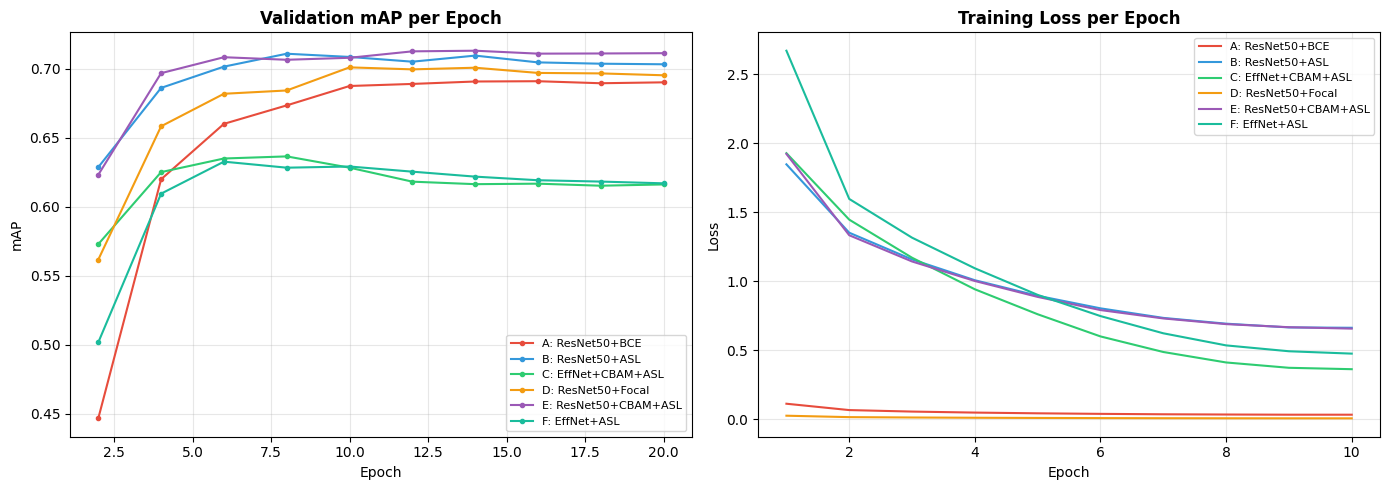

Saved ablation_curves.png


In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS_DIR = Path('/kaggle/working/outputs')
exp_list = [
    ('A: ResNet50+BCE',      'exp_A_resnet_bce'),
    ('B: ResNet50+ASL',      'exp_B_resnet_asl'),
    ('C: EffNet+CBAM+ASL',   'exp_C_efficientnet_cbam_asl'),
    ('D: ResNet50+Focal',    'exp_D_resnet_focal'),
    ('E: ResNet50+CBAM+ASL', 'exp_E_resnet_cbam_asl'),
    ('F: EffNet+ASL',        'exp_F_efficientnet_asl'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for (name, exp_dir), color in zip(exp_list, colors):
    log_path = OUTPUTS_DIR / exp_dir / 'log.json'
    if not log_path.exists():
        continue
    records = json.load(open(log_path))
    epochs = [r['epoch'] for r in records if 'mAP' in r]
    maps   = [r['mAP']   for r in records if 'mAP' in r]
    losses = [r.get('train_loss', None) for r in records]

    axes[0].plot(epochs, maps, marker='o', ms=3, label=name, color=color)
    train_epochs = list(range(1, len(losses)+1))
    axes[1].plot(train_epochs, losses, label=name, color=color)

axes[0].set_title('Validation mAP per Epoch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('mAP')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_title('Training Loss per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'ablation_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved ablation_curves.png')


## Cell 16: Cross-Dataset Evaluation (Pascal VOC 2012)

**Thêm data:** Add Data → gopalbhattrai/pascal-voc-2012-dataset


In [8]:
import os
from pathlib import Path

VOC_ROOT    = '/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test'
OUTPUTS_DIR = '/kaggle/working/outputs'

if os.path.exists(VOC_ROOT):
    print('Starting VOC 2012 cross-evaluation...')
    !python /kaggle/working/ECAAL/src/cross_evaluate.py --voc-root {VOC_ROOT} --outputs-dir {OUTPUTS_DIR}
else:
    print(f'VOC dataset not found at {VOC_ROOT}')
    print('Add Data -> gopalbhattrai/pascal-voc-2012-dataset')


Starting VOC 2012 cross-evaluation...
[VOC 2012 test] 10,991 images loaded

Đang đánh giá VOC cho: exp_C_efficientnet_cbam_asl
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
exp_C_efficientnet_cbam_asl: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_B_resnet_asl
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
exp_B_resnet_asl: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_E_resnet_cbam_asl
[Model] resnet50 | CBAM=True | Params=24.20M | FeatChannels=2048
exp_E_resnet_cbam_asl: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_F_efficientnet_asl
[Model] efficientnet_b0 | CBAM=False | Params=3.62M | FeatChannels=320
exp_F_efficientnet_asl: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_D_resnet_focal
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
exp_D_resnet_focal: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_A_resnet_bce
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
exp_A_resnet_bce: VOC mAP = 0.0000

Đã lưu kết quả v

## Cell 17: COCO Test Evaluation (4k held-out from val2017)


In [9]:
import torch, json
import numpy as np
import pandas as pd
from pathlib import Path
import sys

sys.path.insert(0, str(REPO_DIR / 'src'))
from models import build_model
from dataset import COCOMultiLabelDataset, get_val_transform
from evaluate import compute_map, compute_f1

COCO_ROOT   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
OUTPUTS_DIR = Path('/kaggle/working/outputs')
SUBSET_DIR  = Path('/kaggle/working/data/coco_subset')
DEVICE      = 'cuda'

test_ids = json.load(open(SUBSET_DIR / 'subset_test_ids.json'))
print(f'Test set: {len(test_ids)} images from val2017')

transform   = get_val_transform(img_size=224)
test_ds     = COCOMultiLabelDataset(COCO_ROOT, 'val', transform, test_ids)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64, num_workers=2, pin_memory=True)

EXPERIMENTS = [
    ('A: ResNet50+BCE',      'exp_A_resnet_bce',            'resnet50',        False),
    ('B: ResNet50+ASL',      'exp_B_resnet_asl',            'resnet50',        False),
    ('C: EffNet+CBAM+ASL',   'exp_C_efficientnet_cbam_asl', 'efficientnet_b0', True),
    ('D: ResNet50+Focal',    'exp_D_resnet_focal',          'resnet50',        False),
    ('E: ResNet50+CBAM+ASL', 'exp_E_resnet_cbam_asl',       'resnet50',        True),
    ('F: EffNet+ASL',        'exp_F_efficientnet_asl',      'efficientnet_b0', False),
]

coco_test_results = []
for name, exp_dir, backbone, use_cbam in EXPERIMENTS:
    pth = OUTPUTS_DIR / exp_dir / 'best.pth'
    if not pth.exists():
        print(f'  skip {name} (no best.pth)'); continue
    print(f'\nEvaluating COCO test: {name}')
    model = build_model({'backbone': backbone, 'use_cbam': use_cbam,
                         'num_classes': 80, 'pretrained': False}).to(DEVICE)
    ckpt = torch.load(pth, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt)
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, tgts in test_loader:
            p = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_p.append(p); all_t.append(tgts.numpy())
    P = np.concatenate(all_p); T = np.concatenate(all_t)
    m = {**compute_map(T, P), **compute_f1(T, P)}
    coco_test_results.append({
        'Experiment': name, 'exp_dir': exp_dir,
        'COCO_Test_mAP': round(m['mAP'], 4),
        'COCO_Test_Macro_F1': round(m['macro_f1'], 4),
        'COCO_Test_Micro_F1': round(m['micro_f1'], 4),
    })
    print(f"  mAP={m['mAP']:.4f} | F1={m['macro_f1']:.4f}")

df = pd.DataFrame([{k:v for k,v in r.items() if k!='exp_dir'} for r in coco_test_results])
df.to_csv(OUTPUTS_DIR / 'coco_test_evaluation.csv', index=False)
print('\n' + '='*65)
print('COCO TEST RESULTS (4k held-out from val2017)')
print('='*65)
print(df.to_string(index=False))
print('='*65)


Test set: 3952 images from val2017
[COCO 2017 val] 3,952 images loaded

Evaluating COCO test: A: ResNet50+BCE
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  mAP=0.7081 | F1=0.6486

Evaluating COCO test: B: ResNet50+ASL
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  mAP=0.7228 | F1=0.6159

Evaluating COCO test: C: EffNet+CBAM+ASL
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
  mAP=0.6537 | F1=0.5768

Evaluating COCO test: D: ResNet50+Focal
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  mAP=0.7100 | F1=0.6467

Evaluating COCO test: E: ResNet50+CBAM+ASL
[Model] resnet50 | CBAM=True | Params=24.20M | FeatChannels=2048
  mAP=0.7223 | F1=0.6274

Evaluating COCO test: F: EffNet+ASL
[Model] efficientnet_b0 | CBAM=False | Params=3.62M | FeatChannels=320
  mAP=0.6463 | F1=0.5598

COCO TEST RESULTS (4k held-out from val2017)
          Experiment  COCO_Test_mAP  COCO_Test_Macro_F1  COCO_Test_Micro_F1
     A: Res

## Cell 18: Cross-Dataset Comparison — VOC vs COCO Test



CROSS-DATASET: COCO Test vs VOC (cross-dataset)
          Experiment  COCO_Test_mAP  COCO_Test_Macro_F1  VOC_mAP  VOC_Macro_F1
     B: ResNet50+ASL         0.7228              0.6159      0.0           0.0
E: ResNet50+CBAM+ASL         0.7223              0.6274      0.0           0.0
   D: ResNet50+Focal         0.7100              0.6467      0.0           0.0
     A: ResNet50+BCE         0.7081              0.6486      0.0           0.0
  C: EffNet+CBAM+ASL         0.6537              0.5768      0.0           0.0
       F: EffNet+ASL         0.6463              0.5598      0.0           0.0


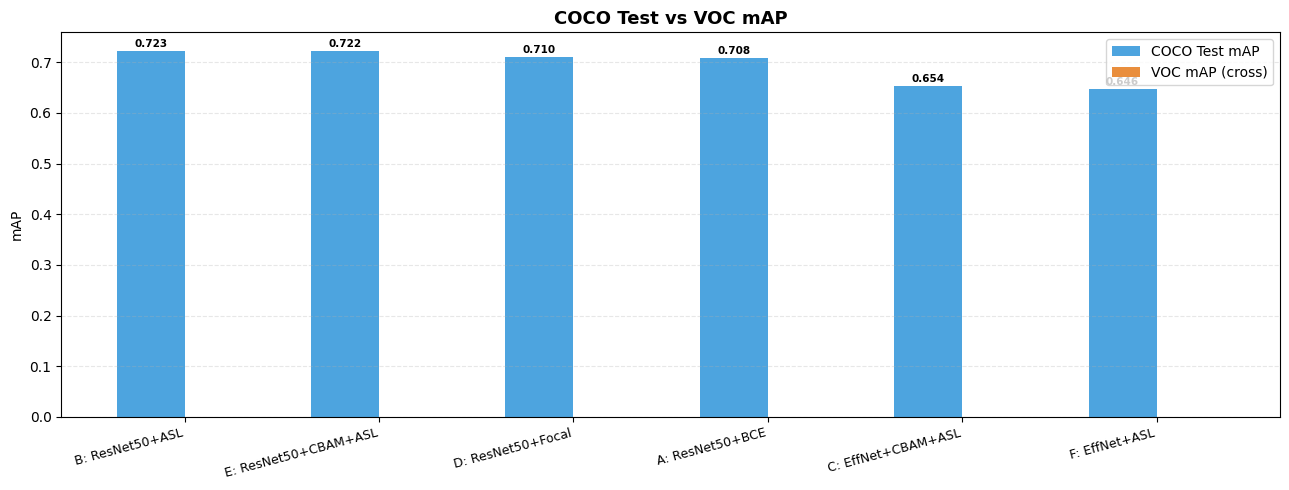

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS_DIR = Path('/kaggle/working/outputs')
voc_csv  = OUTPUTS_DIR / 'voc_cross_evaluation.csv'
coco_csv = OUTPUTS_DIR / 'coco_test_evaluation.csv'

if not voc_csv.exists() or not coco_csv.exists():
    missing = []
    if not voc_csv.exists():  missing.append('voc (Cell 16)')
    if not coco_csv.exists(): missing.append('coco_test (Cell 17)')
    print(f'Missing: {", ".join(missing)}')
else:
    df_voc  = pd.read_csv(voc_csv)
    df_coco = pd.read_csv(coco_csv)

    name_map = {
        'exp_A_resnet_bce':           'A: ResNet50+BCE',
        'exp_B_resnet_asl':           'B: ResNet50+ASL',
        'exp_C_efficientnet_cbam_asl':'C: EffNet+CBAM+ASL',
        'exp_D_resnet_focal':         'D: ResNet50+Focal',
        'exp_E_resnet_cbam_asl':      'E: ResNet50+CBAM+ASL',
        'exp_F_efficientnet_asl':     'F: EffNet+ASL',
    }
    if df_voc['Experiment'].str.startswith('exp_').any():
        df_voc['Experiment'] = df_voc['Experiment'].map(lambda x: name_map.get(x, x))

    df_m = df_coco[['Experiment','COCO_Test_mAP','COCO_Test_Macro_F1']].merge(
        df_voc[['Experiment','VOC_mAP','VOC_Macro_F1']], on='Experiment', how='outer'
    ).sort_values('COCO_Test_mAP', ascending=False).reset_index(drop=True)

    print('\n' + '='*75)
    print('CROSS-DATASET: COCO Test vs VOC (cross-dataset)')
    print('='*75)
    print(df_m.to_string(index=False))
    print('='*75)
    df_m.to_csv(OUTPUTS_DIR / 'cross_dataset_comparison.csv', index=False)

    fig, ax = plt.subplots(figsize=(13, 5))
    x = range(len(df_m)); w = 0.35
    b1 = ax.bar([i-w/2 for i in x], df_m['COCO_Test_mAP'].fillna(0), w,
                label='COCO Test mAP', color='#3498db', alpha=0.88)
    b2 = ax.bar([i+w/2 for i in x], df_m['VOC_mAP'].fillna(0), w,
                label='VOC mAP (cross)', color='#e67e22', alpha=0.88)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_m['Experiment'], rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('mAP'); ax.set_title('COCO Test vs VOC mAP', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+0.004, f'{h:.3f}',
                          ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUTS_DIR / 'cross_dataset_bar.png'), dpi=150, bbox_inches='tight')
    plt.show()


## Cell 19: Overfitting Analysis — Train vs Val vs Test


In [11]:
import torch, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(REPO_DIR / 'src'))
from models import build_model
from dataset import COCOMultiLabelDataset, get_val_transform
from evaluate import compute_map, compute_f1

COCO_ROOT   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
OUTPUTS_DIR = Path('/kaggle/working/outputs')
SUBSET_DIR  = Path('/kaggle/working/data/coco_subset')
DEVICE      = 'cuda'

transform = get_val_transform(img_size=224)
train_ids = json.load(open(SUBSET_DIR / 'subset_train_ids.json'))
train_ds  = COCOMultiLabelDataset(COCO_ROOT, 'train', transform, train_ids)
print(f'Train eval: {len(train_ds.samples)} samples')
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, num_workers=2, pin_memory=True)

EXPERIMENTS = [
    ('A: ResNet50+BCE',      'exp_A_resnet_bce',            'resnet50',        False),
    ('B: ResNet50+ASL',      'exp_B_resnet_asl',            'resnet50',        False),
    ('C: EffNet+CBAM+ASL',   'exp_C_efficientnet_cbam_asl', 'efficientnet_b0', True),
    ('D: ResNet50+Focal',    'exp_D_resnet_focal',          'resnet50',        False),
    ('E: ResNet50+CBAM+ASL', 'exp_E_resnet_cbam_asl',       'resnet50',        True),
    ('F: EffNet+ASL',        'exp_F_efficientnet_asl',      'efficientnet_b0', False),
]

coco_test_csv = OUTPUTS_DIR / 'coco_test_evaluation.csv'
df_test = pd.read_csv(coco_test_csv) if coco_test_csv.exists() else None

rows = []
for name, exp_dir, backbone, use_cbam in EXPERIMENTS:
    pth = OUTPUTS_DIR / exp_dir / 'best.pth'
    log = OUTPUTS_DIR / exp_dir / 'log.json'
    if not pth.exists(): continue
    print(f'\nTrain-eval: {name}')
    model = build_model({'backbone': backbone, 'use_cbam': use_cbam,
                         'num_classes': 80, 'pretrained': False}).to(DEVICE)
    ckpt = torch.load(pth, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt)
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, tgts in train_loader:
            p = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_p.append(p); all_t.append(tgts.numpy())
    P = np.concatenate(all_p); T = np.concatenate(all_t)
    tr = {**compute_map(T, P), **compute_f1(T, P)}

    val_map = val_f1 = None
    if log.exists():
        best = max(json.load(open(log)), key=lambda r: r.get('mAP', 0))
        val_map = round(best.get('mAP', 0), 4)
        val_f1  = round(best.get('macro_f1', 0), 4)

    test_map = test_f1 = None
    if df_test is not None:
        r = df_test[df_test['Experiment'] == name]
        if not r.empty:
            test_map = r.iloc[0].get('COCO_Test_mAP')
            test_f1  = r.iloc[0].get('COCO_Test_Macro_F1')

    train_map = round(tr['mAP'], 4)
    gap_test  = round(train_map - test_map, 4) if test_map else None

    def status(g):
        if g is None: return '?'
        return 'OK' if abs(g) < 0.04 else ('Nhe' if abs(g) < 0.08 else 'OVERFIT')

    print(f'  Train={train_map:.4f} Val={val_map} Test={test_map} Gap={gap_test} {status(gap_test)}')
    rows.append({
        'Experiment': name,
        'Train_mAP': train_map, 'Val_mAP': val_map, 'Test_mAP': test_map,
        'Gap_test': gap_test,
        'Train_F1': round(tr['macro_f1'], 4), 'Val_F1': val_f1, 'Test_F1': test_f1,
    })

if not rows:
    print('No results')
else:
    df = pd.DataFrame(rows).sort_values('Test_mAP', ascending=False, na_position='last').reset_index(drop=True)
    print('\n' + '='*80)
    print('OVERFITTING ANALYSIS: Train vs Val vs Test')
    print('='*80)
    print(df[['Experiment','Train_mAP','Val_mAP','Test_mAP','Gap_test']].to_string(index=False))
    print('='*80)
    for _, r in df.iterrows():
        g = r['Gap_test']
        if g is not None:
            s = 'OK' if abs(g)<0.04 else ('Nhe' if abs(g)<0.08 else 'OVERFIT')
            print(f"  {r['Experiment']:<28} gap={g:+.4f}  {s}")
    df.to_csv(OUTPUTS_DIR / 'overfitting_analysis.csv', index=False)
    print('Saved overfitting_analysis.csv')


[COCO 2017 train] 16,000 images loaded
Train eval: 16000 samples

Train-eval: A: ResNet50+BCE
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  Train=0.8706 Val=0.6908 Test=0.7081 Gap=0.1625 OVERFIT

Train-eval: B: ResNet50+ASL
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  Train=0.8739 Val=0.7107 Test=0.7228 Gap=0.1511 OVERFIT

Train-eval: C: EffNet+CBAM+ASL
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
  Train=0.9168 Val=0.6364 Test=0.6537 Gap=0.2631 OVERFIT

Train-eval: D: ResNet50+Focal
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  Train=0.8665 Val=0.7009 Test=0.71 Gap=0.1565 OVERFIT

Train-eval: E: ResNet50+CBAM+ASL
[Model] resnet50 | CBAM=True | Params=24.20M | FeatChannels=2048
  Train=0.9310 Val=0.7129 Test=0.7223 Gap=0.2087 OVERFIT

Train-eval: F: EffNet+ASL
[Model] efficientnet_b0 | CBAM=False | Params=3.62M | FeatChannels=320
  Train=0.8132 Val=0.6326 Test=0.6463 Gap=0.1669 OVERFIT

OVERFITT

## Cell 20: Zip & Download Results


In [12]:
import os
print('Zipping results (excluding .pth to keep size small)...')
!zip -q -r /kaggle/working/ecaal_eval_results.zip /kaggle/working/outputs -x "*.pth"
print('Done! Download: /kaggle/working/ecaal_eval_results.zip')


Zipping results (excluding .pth to keep size small)...
Done! Download: /kaggle/working/ecaal_eval_results.zip
